In [78]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ethelanaga/divvy-bike-share-data/Divvy_Trips_2020_Q1.csv
/kaggle/input/datasets/ethelanaga/divvy-bike-share-data/Divvy_Trips_2019_Q1.csv


INTRODUCTION

This analysis examines Cyclistic bike-share data from the first quarter (Q1) of 2019 and 2020 to answer the following business question:

How do annual members and casual riders use Cyclistic bikes differently?

The analysis will compare the riding behavior of annual members and casual riders, including the number of rides, average ride length, and riding patterns by day of the week. The data will be cleaned, combined, and analyzed using Python to identify differences and trends between the two rider groups.

The goal of this analysis is to understand how annual members and casual riders use Divvy bikes differently. The insights from this analysis can help Divvy better understand its riders and identify ways to encourage casual riders to become annual members.

The Python libraries used for this analysis include:

Pandas for importing, cleaning, organizing, and analyzing the data.
Matplotlib for creating visualizations and presenting the findings.

Load Libraries

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

Import the Data

The Q1 2019 and Q1 2020 Divvy trip CSV datasets were imported into Python. The datasets contain information about individual bike trips, including rider type, trip start and end times, and station information. The two datasets were reviewed to understand their structure and identify differences between the available columns.

In [80]:
q1_2019 = pd.read_csv("/kaggle/input/datasets/ethelanaga/divvy-bike-share-data/Divvy_Trips_2019_Q1.csv")
q1_2020 = pd.read_csv("/kaggle/input/datasets/ethelanaga/divvy-bike-share-data/Divvy_Trips_2020_Q1.csv")

Explore the Data

Explored Data to compare column names for each file.

Column Names

In [81]:
print("Columns for Q1 2019:\n", q1_2019.columns)
print("\nColumns for Q1 2020:\n", q1_2020.columns)

Columns for Q1 2019:
 Index(['trip_id', 'start_time', 'end_time', 'bikeid', 'tripduration',
       'from_station_id', 'from_station_name', 'to_station_id',
       'to_station_name', 'usertype', 'gender', 'birthyear'],
      dtype='object')

Columns for Q1 2020:
 Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual'],
      dtype='object')


Rename Columns

In [82]:
q1_2019 = q1_2019.rename(columns={
    'trip_id': 'ride_id',
        'bikeid': 'rideable_type',
    'start_time': 'started_at',
    'end_time': 'ended_at',
    'from_station_name': 'start_station_name',
    'from_station_id': 'start_station_id',
    'to_station_name': 'end_station_name',
    'to_station_id': 'end_station_id',
    'usertype': 'member_casual'
})


Inspect the data frames and look for incongruities

In [83]:
print("\nQ1 2019 Data Info:")
q1_2019.info()
print("\nQ1 2020 Data Info:")
q1_2020.info()



Q1 2019 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365069 entries, 0 to 365068
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             365069 non-null  int64  
 1   started_at          365069 non-null  object 
 2   ended_at            365069 non-null  object 
 3   rideable_type       365069 non-null  int64  
 4   tripduration        365069 non-null  object 
 5   start_station_id    365069 non-null  int64  
 6   start_station_name  365069 non-null  object 
 7   end_station_id      365069 non-null  int64  
 8   end_station_name    365069 non-null  object 
 9   member_casual       365069 non-null  object 
 10  gender              345358 non-null  object 
 11  birthyear           347046 non-null  float64
dtypes: float64(1), int64(4), object(7)
memory usage: 33.4+ MB

Q1 2020 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426887 entries, 0 to 426886
Data col

Convert ride_id and rideable_type to string so that they can stack correctly

In [84]:
q1_2019['ride_id'] = q1_2019['ride_id'].astype(str)
q1_2019['rideable_type'] = q1_2019['rideable_type'].astype(str)


Stack individual quarter's data frames into one big data frame

In [85]:
all_trips = pd.concat([q1_2019, q1_2020], ignore_index=True)

Remove lat, long, birthyear, and gender fields as this data was dropped beginning in 2020
The 'errors="ignore"' argument prevents an error if a column is not found


In [86]:

all_trips = all_trips.drop(columns=['start_lat', 'start_lng', 'end_lat', 'end_lng', 'birthyear', 'gender', 'tripduration'], errors='ignore')


Data Clean up and Preparation 

The datasets were cleaned and prepared. The data was checked for missing values, invalid values, and inconsistencies in the trip information. A ride_length variable was created to measure the length of each ride using the recorded start and end times. Records with negative or invalid ride lengths were removed, particularly from the 2020 dataset, where some recorded trip times produced invalid ride lengths. These records were excluded because keeping them could distort the analysis of ride duration and produce inaccurate comparisons between members and casual riders. After cleaning, the datasets were combined for analysis. 
Below are the processes.


Inspect the new table that has been created

In [87]:
print("\nList of column names:\n", all_trips.columns)
print("\nHow many rows are in data frame?", len(all_trips))
print("\nDimensions of the data frame:", all_trips.shape)
print("\nSee the first 6 rows of data frame:\n", all_trips.head())
print("\nSee list of columns and data types:\n")


List of column names:
 Index(['ride_id', 'started_at', 'ended_at', 'rideable_type',
       'start_station_id', 'start_station_name', 'end_station_id',
       'end_station_name', 'member_casual'],
      dtype='object')

How many rows are in data frame? 791956

Dimensions of the data frame: (791956, 9)

See the first 6 rows of data frame:
     ride_id           started_at             ended_at rideable_type  \
0  21742443  2019-01-01 00:04:37  2019-01-01 00:11:07          2167   
1  21742444  2019-01-01 00:08:13  2019-01-01 00:15:34          4386   
2  21742445  2019-01-01 00:13:23  2019-01-01 00:27:12          1524   
3  21742446  2019-01-01 00:13:45  2019-01-01 00:43:28           252   
4  21742447  2019-01-01 00:14:52  2019-01-01 00:20:56          1170   

   start_station_id                   start_station_name  end_station_id  \
0               199               Wabash Ave & Grand Ave            84.0   
1                44               State St & Randolph St           624.0   
2   

Statistical summary of data (mainly for numerics)

In [88]:

print("\nStatistical summary of data:\n", all_trips.describe())



Statistical summary of data:
        start_station_id  end_station_id
count     791956.000000   791955.000000
mean         204.400294      204.379354
std          158.919132      159.323552
min            2.000000        2.000000
25%           77.000000       77.000000
50%          174.000000      174.000000
75%          291.000000      291.000000
max          675.000000      675.000000


In [89]:
all_trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791956 entries, 0 to 791955
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             791956 non-null  object 
 1   started_at          791956 non-null  object 
 2   ended_at            791956 non-null  object 
 3   rideable_type       791956 non-null  object 
 4   start_station_id    791956 non-null  int64  
 5   start_station_name  791956 non-null  object 
 6   end_station_id      791955 non-null  float64
 7   end_station_name    791955 non-null  object 
 8   member_casual       791956 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 54.4+ MB


In the "member_casual" column, there are two names for members ("member" and "Subscriber") and two names for casual riders ("Customer" and "casual").these names were consolidated to” Member” and ”Casual’. I added some additional columns of data -- such as day, month, year -- that provide additional opportunities to aggregate the data. I also added a calculated field for length of ride since the 2020-Q1 data did not have the "tripduration" column. I added "ride_length" to the entire data frame for consistency. There are some rides where tripduration shows up as negative, including several hundred rides which the data were incomplete, these were deleted. See below

In [90]:
print("\nValue counts for 'member_casual' column before cleaning:\n", all_trips['member_casual'].value_counts())


Value counts for 'member_casual' column before cleaning:
 member_casual
member        378407
Subscriber    341906
casual         48480
Customer       23163
Name: count, dtype: int64


In the "member_casual" column, replace "Subscriber" with "member" and "Customer" with "casual"

In [91]:
all_trips['member_casual'] = all_trips['member_casual'].replace({
    'Subscriber': 'member',
    'Customer': 'casual'
})


Check if replaced

In [92]:
print("\nValue counts for 'member_casual' column after cleaning:\n", all_trips['member_casual'].value_counts())


Value counts for 'member_casual' column after cleaning:
 member_casual
member    720313
casual     71643
Name: count, dtype: int64


Convert 'started_at' and 'ended_at' to datetime objects

In [93]:
all_trips['started_at'] = pd.to_datetime(all_trips['started_at'])
all_trips['ended_at'] = pd.to_datetime(all_trips['ended_at'])


Add columns that list the date, month, day, and year of each ride

In [94]:
all_trips['date'] = all_trips['started_at'].dt.date
all_trips['month'] = all_trips['started_at'].dt.month
all_trips['day'] = all_trips['started_at'].dt.day
all_trips['year'] = all_trips['started_at'].dt.year
all_trips['day_of_week'] = all_trips['started_at'].dt.day_name()


Add a "ride_length" calculation to all_trips (in seconds)

In [95]:
all_trips['ride_length'] = (all_trips['ended_at'] - all_trips['started_at']).dt.total_seconds()

Inspect the structure of the columns

In [96]:
print("\nData types after adding date columns and ride_length:\n")
all_trips.info()



Data types after adding date columns and ride_length:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791956 entries, 0 to 791955
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   ride_id             791956 non-null  object        
 1   started_at          791956 non-null  datetime64[ns]
 2   ended_at            791956 non-null  datetime64[ns]
 3   rideable_type       791956 non-null  object        
 4   start_station_id    791956 non-null  int64         
 5   start_station_name  791956 non-null  object        
 6   end_station_id      791955 non-null  float64       
 7   end_station_name    791955 non-null  object        
 8   member_casual       791956 non-null  object        
 9   date                791956 non-null  object        
 10  month               791956 non-null  int32         
 11  day                 791956 non-null  int32         
 12  year                791956 non

Remove "bad" data
The data frame includes entries where bikes were taken out of docks for quality checks or ride_length was negative
Create a new version of the data frame (v2) since data is being removed


In [97]:
all_trips_v2 = all_trips[(all_trips['start_station_name'] != "HQ QR") & (all_trips['ride_length'] >= 0)].copy()

Descriptive Statistics and Analysis

Descriptive Statistics and Analysis was performed to understand the overall riding behavior of the two rider groups. The analysis focused on:
•	Number of rides by rider type,
•	Average ride length by rider type
•	Number of rides by rider type and day of the week Average
•	Ride length by rider type and day of the week 
These measures were used to identify differences in how frequently members and casual riders use the service and how long they typically ride.



Descriptive analysis on ride_length (all figures in seconds)

In [98]:
print("\nDescriptive statistics for ride_length:\n", all_trips_v2['ride_length'].describe())


Descriptive statistics for ride_length:
 count    7.881890e+05
mean     1.189459e+03
std      3.329191e+04
min      1.000000e+00
25%      3.310000e+02
50%      5.390000e+02
75%      9.120000e+02
max      1.063202e+07
Name: ride_length, dtype: float64


Compare members and casual users

In [99]:
print("\nRide length statistics grouped by member_casual:\n", all_trips_v2.groupby('member_casual')['ride_length'].agg(['mean', 'median', 'max', 'min']))


Ride length statistics grouped by member_casual:
                       mean  median         max  min
member_casual                                      
casual         5372.783874  1393.0  10632022.0  2.0
member          795.252339   508.0   6096428.0  1.0


See the average ride time by each day for members vs casual users

In [100]:
print("\nAverage ride length by member type and day of the week:\n", all_trips_v2.groupby(['member_casual', 'day_of_week'])['ride_length'].mean())


Average ride length by member type and day of the week:
 member_casual  day_of_week
casual         Friday         6090.737302
               Monday         4752.050438
               Saturday       4950.770801
               Sunday         5061.304364
               Thursday       8451.666853
               Tuesday        4561.803857
               Wednesday      4480.372432
member         Friday          796.733789
               Monday          822.311202
               Saturday        974.072964
               Sunday          972.938336
               Thursday        707.209274
               Tuesday         769.441629
               Wednesday       711.983790
Name: ride_length, dtype: float64


Ordered the days of the week for correct sorting for analysis
days_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]


In [101]:
days_order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
all_trips_v2['day_of_week'] = pd.Categorical(all_trips_v2['day_of_week'], categories=days_order, ordered=True)

Check result

In [102]:
print("\nAverage ride length (sorted by day of week):\n", all_trips_v2.groupby(['member_casual', 'day_of_week'],observed=False)['ride_length'].mean())


Average ride length (sorted by day of week):
 member_casual  day_of_week
casual         Sunday         5061.304364
               Monday         4752.050438
               Tuesday        4561.803857
               Wednesday      4480.372432
               Thursday       8451.666853
               Friday         6090.737302
               Saturday       4950.770801
member         Sunday          972.938336
               Monday          822.311202
               Tuesday         769.441629
               Wednesday       711.983790
               Thursday        707.209274
               Friday          796.733789
               Saturday        974.072964
Name: ride_length, dtype: float64


Analyze ridership data by type and weekday

In [103]:
summary_stats = all_trips_v2.groupby(
    ['member_casual', 'day_of_week'],
    observed=False
).agg(
    number_of_rides=('ride_id', 'count'),
    average_duration=('ride_length', 'mean')
).reset_index()

In [104]:
print("\nSummary of rides and duration by rider type and weekday:\n", summary_stats)


Summary of rides and duration by rider type and weekday:
    member_casual day_of_week  number_of_rides  average_duration
0         casual      Sunday            18652       5061.304364
1         casual      Monday             5591       4752.050438
2         casual     Tuesday             7311       4561.803857
3         casual   Wednesday             7690       4480.372432
4         casual    Thursday             7147       8451.666853
5         casual      Friday             8013       6090.737302
6         casual    Saturday            13473       4950.770801
7         member      Sunday            60197        972.938336
8         member      Monday           110430        822.311202
9         member     Tuesday           127974        769.441629
10        member   Wednesday           121902        711.983790
11        member    Thursday           125228        707.209274
12        member      Friday           115168        796.733789
13        member    Saturday            59413

The number of rides by rider type and weekday

In [105]:
rides_by_day = all_trips_v2.groupby(
    ['day_of_week', 'member_casual'],observed=False).size().unstack(fill_value=0)

rides_by_day['Total'] = rides_by_day.sum(axis=1)

print(rides_by_day)

print("\nTotal rides by rider type:")
print(all_trips_v2['member_casual'].value_counts())

print("\nGrand total rides:")
print(len(all_trips_v2))

member_casual  casual  member   Total
day_of_week                          
Sunday          18652   60197   78849
Monday           5591  110430  116021
Tuesday          7311  127974  135285
Wednesday        7690  121902  129592
Thursday         7147  125228  132375
Friday           8013  115168  123181
Saturday        13473   59413   72886

Total rides by rider type:
member_casual
member    720312
casual     67877
Name: count, dtype: int64

Grand total rides:
788189


The average ride duration by rider type and weekday 

In [106]:
avg_ride_by_day = all_trips_v2.groupby(
    ['day_of_week', 'member_casual'],observed=False
)['ride_length'].mean().unstack()

print(avg_ride_by_day)

print("\nOverall average ride length by rider type:")
print(all_trips_v2.groupby('member_casual')['ride_length'].mean())

member_casual       casual      member
day_of_week                           
Sunday         5061.304364  972.938336
Monday         4752.050438  822.311202
Tuesday        4561.803857  769.441629
Wednesday      4480.372432  711.983790
Thursday       8451.666853  707.209274
Friday         6090.737302  796.733789
Saturday       4950.770801  974.072964

Overall average ride length by rider type:
member_casual
casual    5372.783874
member     795.252339
Name: ride_length, dtype: float64


Visualizations:

Six charts were created to communicate the findings. The visualizations show differences between annual members and casual riders in areas including: 

Number of rides by rider type.

Average ride length by rider type.

Number of rides by rider type and day of the week. 

Number of rides by rider type and day of the week using an alternative visualization

Average ride length by rider type and day of the week.

Average ride length by rider type and day of the week using an alternative.

visualization The visualizations provide a clear picture of the differences between the two rider groups and make the patterns in the data easier to interpret.

Number of Rides by Rider Type

This showed that members took significantly more rides than casual riders. The data contained approximately:
•	720,312 member rides
•	67,877 casual rides 
This indicates that members use the bike-share service much more frequently than casual riders. The difference in the number of rides suggests that members are more frequent users of the service, while casual riders use the bikes less often. 
Figure 1: Number of Rides by Rider Type


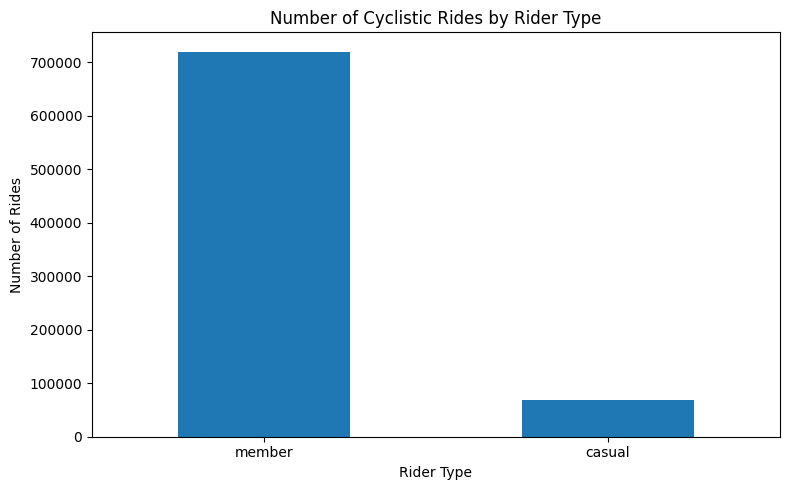

In [107]:
ride_counts = all_trips_v2['member_casual'].value_counts()

plt.figure(figsize=(8, 5))
ride_counts.plot(kind='bar')

plt.title('Number of Cyclistic Rides by Rider Type')
plt.xlabel('Rider Type')
plt.ylabel('Number of Rides')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig('1_number_of_rides_by_rider_type.png',dpi=300,bbox_inches='tight')

plt.show()

Figure 1: Number of Rides by Rider Type

Average Ride Length by Rider Type

The average ride length was:
•	Members: approximately 795 seconds
•	Casual riders: approximately 5,373 seconds 
This shows a substantial difference in ride duration between the two groups. Although members take many more rides, casual riders tend to spend much longer on each individual ride. This difference suggests that the two rider groups may use the bike-share service for different purposes or in different ways. 
Figure 2: Average Ride Length by Rider Type



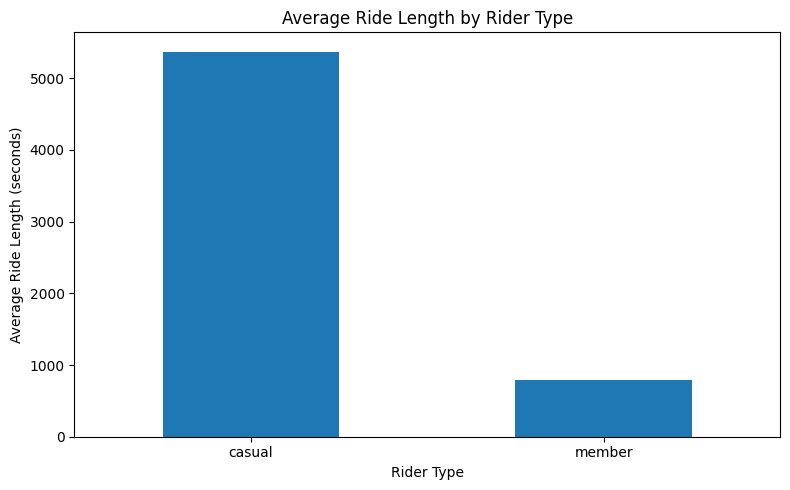

In [108]:
avg_ride = all_trips_v2.groupby('member_casual')['ride_length'].mean()

plt.figure(figsize=(8, 5))
avg_ride.plot(kind='bar')

plt.title('Average Ride Length by Rider Type')
plt.xlabel('Rider Type')
plt.ylabel('Average Ride Length (seconds)')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig('2_average_ride_length_by_rider_type.png',dpi=300,bbox_inches='tight')
plt.show()

Figure 2: Average Ride Length by Rider Type

Number of Rides By Rider Type and Day of week

This compared the number of rides taken by members and casual riders across each day of the week. 
The purpose of this analysis was to determine whether the frequency of bike use differ between the two rider types and whether there are differences in their usage patterns throughout the week. 
The analysis shows that members took considerably more rides than casual riders across the days analyzed. The data by day of the week also helps identify when each rider group is most active. These differences provide useful information for understanding rider behavior and can help Cyclistic develop targeted strategies for casual riders. 
Figure 3: Number of Rides by Rider Type and Day of Week
 Figure 4: Number of Rides by Rider Type and Day of Week — Alternative Visualization


<Figure size 1000x600 with 0 Axes>

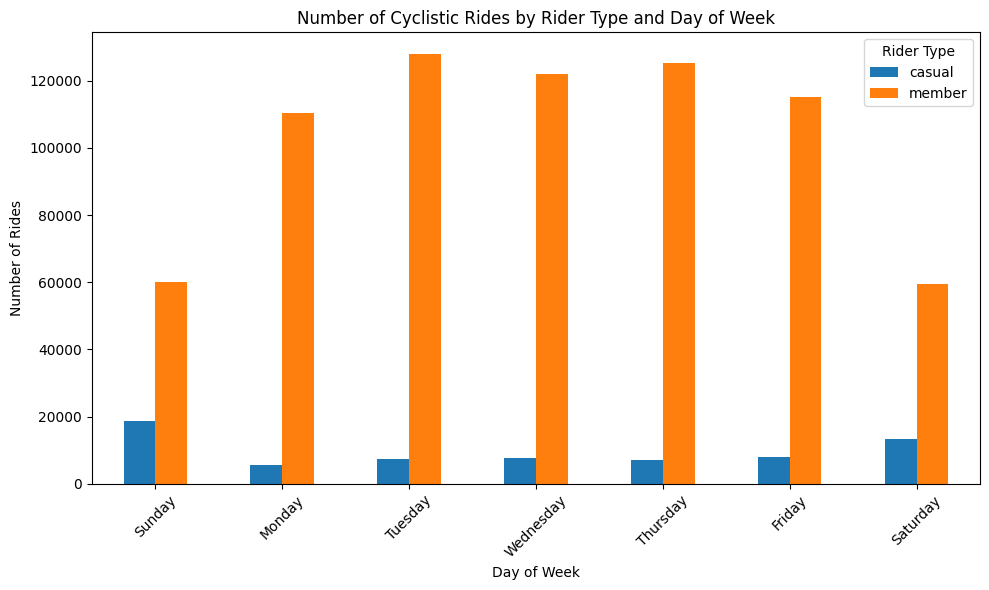

In [109]:
rides_by_day = all_trips_v2.groupby(
    ['day_of_week', 'member_casual'],observed=False
).size().unstack()

day_order = [
    'Sunday', 'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday'
]

rides_by_day = rides_by_day.reindex(day_order)

plt.figure(figsize=(10, 6))
rides_by_day.plot(kind='bar', figsize=(10, 6))

plt.title('Number of Cyclistic Rides by Rider Type and Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.legend(title='Rider Type')
plt.tight_layout()

plt.savefig('3_number_of_rides_by_rider_type_and_day.png',dpi=300,bbox_inches='tight')

plt.show()

Figure 3: Number of Rides by Rider Type and Day of Week

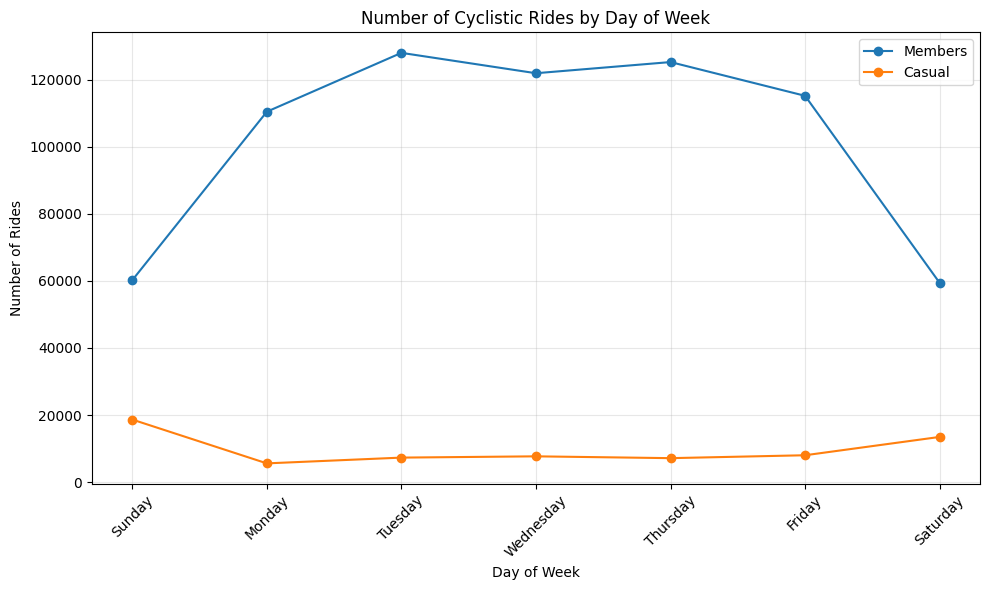

In [110]:
rides_by_day = all_trips_v2.groupby(
    ['day_of_week', 'member_casual'],observed=False
).size().unstack()

day_order = [
    'Sunday', 'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday'
]

rides_by_day = rides_by_day.reindex(day_order)

plt.figure(figsize=(10, 6))

plt.plot(rides_by_day.index, rides_by_day['member'], 
         marker='o', label='Members')

plt.plot(rides_by_day.index, rides_by_day['casual'], 
         marker='o', label='Casual')

plt.title('Number of Cyclistic Rides by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('5_number_of_rides_by_day.png',dpi=300,bbox_inches='tight')

plt.show()

Figure 4: Number of Rides by Rider Type and Day of Week — Alternative Visualization

Average Ride Length by Rider Type and Day of week

This compared the average ride length of members and casual riders across each day of week. The purpose of this analysis was to determine whether ride duration differs between the two rider types and whether this different change depends on the day of the week. The analysis shows that casual riders generally have longer rides than members. This is consistent with the overall average ride-length comparison, where members had an average ride length of approximately 795 seconds, compared with approximately 5,373 seconds for casual riders. Members use the service more frequently, while casual riders tend to spend more time on each ride. These differences provide additional information about the riding behavior of the two groups and can be useful when developing targeted marketing strategies. Figure 5: Average Ride Length by Rider Type and Day of Week Figure 6: Average Ride Length by Rider Type and Day of Week — Alternative Visualization

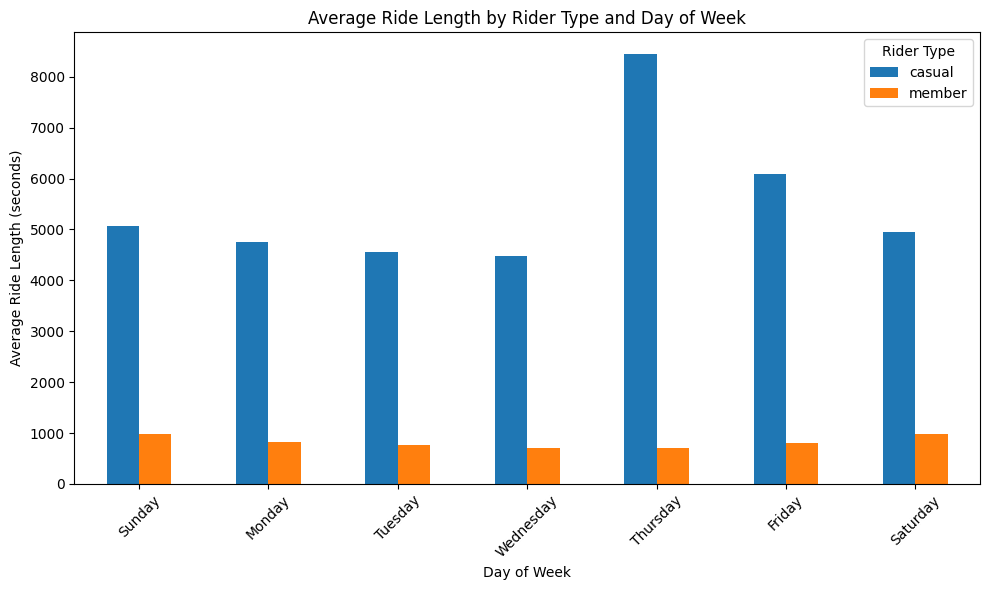

In [111]:
avg_ride_by_day = all_trips_v2.groupby(
    ['day_of_week', 'member_casual'],observed=False
)['ride_length'].mean().unstack()

day_order = [
    'Sunday', 'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday'
]

avg_ride_by_day = avg_ride_by_day.reindex(day_order)

avg_ride_by_day.plot(kind='bar', figsize=(10, 6))

plt.title('Average Ride Length by Rider Type and Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Ride Length (seconds)')
plt.xticks(rotation=45)
plt.legend(title='Rider Type')
plt.tight_layout()

plt.savefig('4_average_ride_length_by_rider_type_and_day.png',dpi=300,bbox_inches='tight')

plt.show()

Figure 5: Average Ride Length by Rider Type and Day of Week

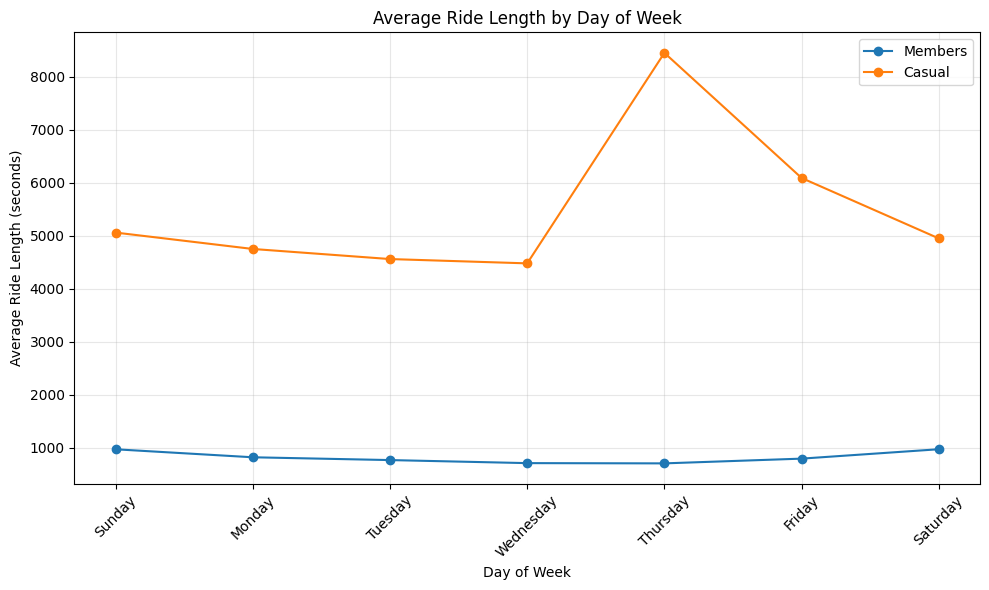

In [112]:
avg_ride_by_day = all_trips_v2.groupby(
    ['day_of_week', 'member_casual'],observed=False
)['ride_length'].mean().unstack()

avg_ride_by_day = avg_ride_by_day.reindex(day_order)

plt.figure(figsize=(10, 6))

plt.plot(avg_ride_by_day.index, avg_ride_by_day['member'], 
         marker='o', label='Members')

plt.plot(avg_ride_by_day.index, avg_ride_by_day['casual'], 
         marker='o', label='Casual')

plt.title('Average Ride Length by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Ride Length (seconds)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('6_average_ride_length_by_day.png',dpi=300,bbox_inches='tight')

plt.show()

Figure 6: Average Ride Length by Rider Type and Day of Week — Alternative Visualization

Overall Statistics

The cleaned descriptive statistics were: 
Number of rides - 788,189 
Mean ride length| - 1,189 seconds 
Median ride length - 539 seconds
Minimum - 1 second 
25th percentile - 331 seconds
75th percentile - 912 seconds 
Maximum - Approximately 10.6 million seconds. 
The mean ride length is considerably higher than the median. This occurs because a small number of extremely long rides increased the average. This indicates that the ride-length distribution is strongly right-skewed. 
The median of 539 seconds provides a better representation of a typical ride than the mean because it is less affected by extremely long rides. The percentiles provide additional information about the distribution of ride lengths.
•	The 25th percentile of 331 seconds means that 25% of rides lasted 331 seconds or less, while 75% lasted longer than 331 seconds.
•	The 75th percentile of 912 seconds means that 75% of rides lasted 912 seconds or less, while 25% lasted longer than 912 seconds. The very large maximum ride length also demonstrates the presence of extreme values in the dataset and helps explain why the mean is substantially higher than the median.



Share and Act:

Key findings:

The analysis identified several important differences between members and casual riders.

members take significantly more rides than casual riders. This suggests that members use the bike-share service more frequently.

Casual riders have a much longer average ride length than members. The average ride length was approximately 795 seconds for members, compared with approximately 5,373 seconds for casual riders.

The analysis of riding patterns by day of the week shows that the two groups do not use the service in exactly the same way.

Overall, the findings indicate that members are more frequent users, while casual riders tend to take longer individual rides. These differences provide an opportunity for Cyclistic to develop targeted strategies to convert casual riders their members.

Recommendations:

Based on the analysis, Cyclistic should focus on converting casual riders to their members. Recommendation 1:Cyclistic should develop membership promotions specifically for casual riders.Since casual riders already use the bike-share service, they represent a potential group of customers who may be interested in becoming members.

Recommendation 2:Cyclistic should clearly communicate the benefits of membership and explain how membership can provide greater value to riders who use Cyclistic regularly. Promotions could emphasize the convenience and potential value of membership compared with continuing to ride as a casual customer.

Recommendation 3:Cyclistic can use the differences in riding behavior by day of the week to determine when casual riders are most active. in this case, Thursday is the hightest ride length day, so membership promotions can then be targeted during this period.

Recommendation 4: Continue Monitoring Rider Behavior Cyclistic should continue analyzing member and casual rider data over time. Monitoring changes in ride frequency, ride length, and usage patterns can help determine whether membership campaigns are successful and whether rider behavior changes after promotional campaigns.

Conclusion:

The analysis shows that members and casual riders use Cyclistic bikes differently. Members take substantially more rides than casual riders, indicating more frequent use of the service. In contrast, casual riders have considerably longer average ride lengths.
These differences suggest that casual riders represent an important opportunity for Cyclistic to increase membership.
By targeting casual riders with appropriate promotions, communicating the value of membership, and using riding patterns to guide marketing efforts, Cyclistic may be able to convert more casual riders to their members.
The analysis provides a data-driven basis for understanding rider behavior and developing marketing strategies to support membership growth.


 References:
1. Google Data Analytics Professional Certificate. Coursera. Case study guidance and data analysis concepts.
2. Divvy Bikes. Divvy bike-share trip data. Q1 2019 and Q1 2020 trip datasets used for this analysis.
3. Python Software Foundation. Python documentation. Reference for Python programming used in the analysis.
4. Pandas Documentation. Reference for importing, cleaning, organizing, and analyzing the datasets.
5. Matplotlib Documentation. Reference for creating data visualizations.


Export Summary File For Further Analysis

In [ ]:
counts = all_trips_v2.groupby(['member_casual', 'day_of_week'],observed=False)['ride_length'].mean().reset_index()
counts.to_csv('avg_ride_length.csv', index=False)

